In [ ]:
# Install libraries: (UNCOMMENT if you need to install them)
# !pip install pandas
# !pip install matplotlib

In [ ]:
# Import libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset of emails
df = pd.read_csv("sample_emails.csv")
# Display the first few rows of the dataset to understand its structure
df.head()

,sender,subject,links,attachment,urgent_words,status
0,security-update@paypaI.com,Reset Password,http://fake-login.com,yes,yes,suspicious
1,hr@company.com,Meeting Reminder,no,no,no,safe
2,support@amaz0n.com,Account Verification,http://secure-amazon-login.net,yes,yes,suspicious
3,admin@bankofamerica.co,Security Alert,http://boa-update.com,no,yes,suspicious
4,it@google-support.org,Email Update Required,http://gmail-fix.org,yes,no,suspicious


In [ ]:
# Get summary information about the dataset, including data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sender        17 non-null     str  
 1   subject       17 non-null     str  
 2   links         17 non-null     str  
 3   attachment    17 non-null     str  
 4   urgent_words  17 non-null     str  
 5   status        17 non-null     str  
dtypes: str(6)
memory usage: 948.0 bytes


In [ ]:
# Check for missing values in each column
df.isnull().sum()

sender          0
subject         0
links           0
attachment      0
urgent_words    0
status          0
dtype: int64

In [ ]:
# Analyze the distribution of email statuses (e.g., "phishing", "legitimate", "suspicious")
df["status"].value_counts()

status
suspicious    11
safe           6
Name: count, dtype: int64

In [ ]:
# Identify suspicious domains in the sender's email address
df["suspicious_domain"] = df["sender"].str.contains("paypaI|micros0ft|arnazon", case=False)

In [ ]:
# Check for urgent language in the email
df["has_urgent_language"] = df["urgent_words"] == "yes"

In [ ]:
# Check for attachments in the email
df["has_attachment"] = df["attachment"] == "yes"

In [ ]:
# Create a risk score based on the presence of suspicious domains, urgent language, and attachments
df["risk_score"] = (
    df["suspicious_domain"].astype(int) * 2 +
    df["has_urgent_language"].astype(int) +
    df["has_attachment"].astype(int)
)

In [ ]:
# Classify the risk level based on the risk score
def classify_risk(score):
    if score >= 3:
        return "high"
    elif score >= 2:
        return "medium"
    else:
        return "low"

df["risk_level"] = df["risk_score"].apply(classify_risk)

In [ ]:
# Display the emails classified as high risk
high_risk = df[df["risk_level"] == "high"]
print(high_risk[["sender", "subject", "risk_score"]])

                       sender         subject  risk_score
0  security-update@paypaI.com  Reset Password           4


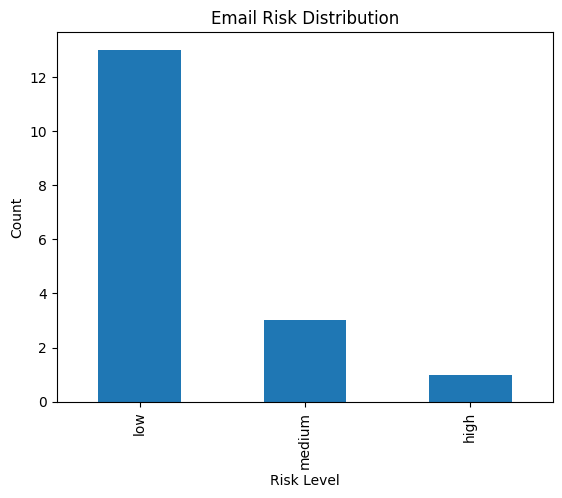

In [ ]:
# Visualize the distribution of risk levels
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Email Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

In [17]:
# Analyze the most common senders of suspicious emails
df[df["suspicious_domain"] == True]["sender"].value_counts()

sender
security-update@paypaI.com    1
Name: count, dtype: int64

In [18]:
# Analyze the presence of urgent language in the emails
df["has_urgent_language"].value_counts()

has_urgent_language
False    9
True     8
Name: count, dtype: int64

In [19]:
# Create a new column to indicate whether the email should be escalated for further review based on the risk score
df["escalate"] = df["risk_score"] >= 3

In [20]:
# Display the relevant columns for further analysis
df[["sender", "risk_score", "risk_level", "escalate"]]

,sender,risk_score,risk_level,escalate
0,security-update@paypaI.com,4,high,True
1,hr@company.com,0,low,False
2,support@amaz0n.com,2,medium,False
3,admin@bankofamerica.co,1,low,False
4,it@google-support.org,1,low,False
5,billing@netfl1x.com,1,low,False
6,alert@apple-id.com,2,medium,False
7,service@microsoft-outlook.net,0,low,False
8,update@facebook-security.com,2,medium,False
9,info@paypal-security.org,1,low,False


In [21]:
# Extract the high-risk cases for further investigation
high_risk_cases = df[df["risk_level"] == "high"]

In [30]:
# Save the high-risk cases to a new CSV file for further analysis
high_risk_cases.to_csv("Reports/high_risk_cases.csv", index=False)

In [23]:
# Create Threat Summary Metrics
total_emails = len(df)
high_risk = len(df[df["risk_level"] == "high"])
medium_risk = len(df[df["risk_level"] == "medium"])
safe_emails = len(df[df["risk_level"] == "low"])

In [24]:
# Print the summary metrics
print("Total Emails:", total_emails)
print("High Risk:", high_risk)
print("Medium Risk:", medium_risk)
print("Low Risk:", safe_emails)

Total Emails: 17
High Risk: 1
Medium Risk: 3
Low Risk: 13


# Create Multiple Visualizations

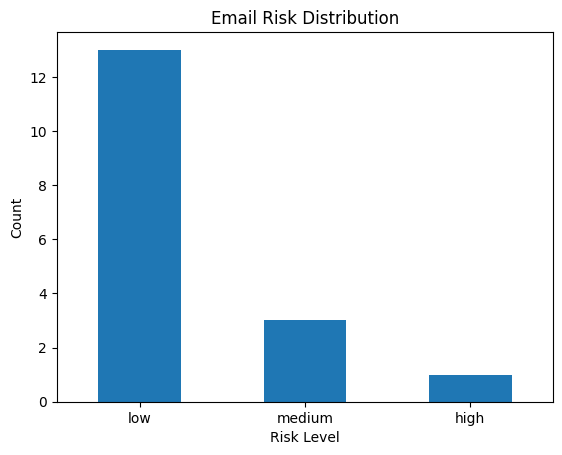

In [25]:
# Chart 1 — Risk Distribution
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Email Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

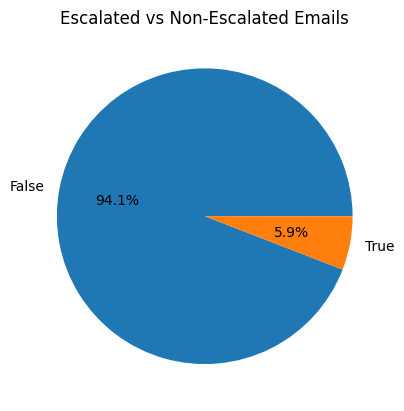

In [26]:
# Chart 2 — Escalated Cases
df["escalate"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Escalated vs Non-Escalated Emails")
plt.ylabel("")
plt.show()

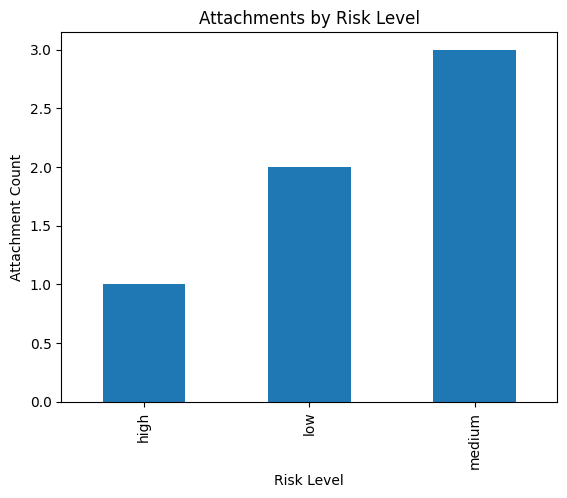

In [27]:
# Chart 3 — Suspicious Attachments
df.groupby("risk_level")["has_attachment"].sum().plot(kind="bar")
plt.title("Attachments by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Attachment Count")
plt.show()

# Build First Automated Threat Flagging

In [28]:
# Create a new column to automatically flag emails that are high risk for further review
def auto_flag(row):
    if row["risk_score"] >= 3:
        return "FLAGGED"
    return "NORMAL"

df["auto_flag"] = df.apply(auto_flag, axis=1)

In [29]:
# Test the auto_flag function by displaying the relevant columns
df[["sender", "risk_score", "auto_flag"]]

,sender,risk_score,auto_flag
0,security-update@paypaI.com,4,FLAGGED
1,hr@company.com,0,NORMAL
2,support@amaz0n.com,2,NORMAL
3,admin@bankofamerica.co,1,NORMAL
4,it@google-support.org,1,NORMAL
5,billing@netfl1x.com,1,NORMAL
6,alert@apple-id.com,2,NORMAL
7,service@microsoft-outlook.net,0,NORMAL
8,update@facebook-security.com,2,NORMAL
9,info@paypal-security.org,1,NORMAL
